In [1]:
# loading the Libaries 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from ucimlrepo import fetch_ucirepo

wine = fetch_ucirepo(id=186)

In [3]:
print(type(wine))
print()
print(wine.shape)
print()
print(wine.keys())

<class 'ucimlrepo.dotdict.dotdict'>

None

dict_keys(['data', 'metadata', 'variables'])


In [4]:
# Understanding the Data 

print(wine.data.keys())
print()
for key, values in wine.metadata.items():
    print(f'{key}: {values}\n')
print()
print(wine.variables)

dict_keys(['ids', 'features', 'targets', 'original', 'headers'])

uci_id: 186

name: Wine Quality

repository_url: https://archive.ics.uci.edu/dataset/186/wine+quality

data_url: https://archive.ics.uci.edu/static/public/186/data.csv

abstract: Two datasets are included, related to red and white vinho verde wine samples, from the north of Portugal. The goal is to model wine quality based on physicochemical tests (see [Cortez et al., 2009], http://www3.dsi.uminho.pt/pcortez/wine/).

area: Business

tasks: ['Classification', 'Regression']

characteristics: ['Multivariate']

num_instances: 4898

num_features: 11

feature_types: ['Real']

demographics: []

target_col: ['quality']

index_col: None

has_missing_values: no

missing_values_symbol: None

year_of_dataset_creation: 2009

last_updated: Wed Nov 15 2023

dataset_doi: 10.24432/C56S3T

creators: ['Paulo Cortez', 'A. Cerdeira', 'F. Almeida', 'T. Matos', 'J. Reis']

intro_paper: {'ID': 252, 'type': 'NATIVE', 'title': 'Modeling wine pref

In [5]:
# convert to df for visualisation and exploration

df = pd.DataFrame(wine.data.features, columns=wine.data.headers)
df['quality'] = wine.data.targets

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed_acidity         6497 non-null   float64
 1   volatile_acidity      6497 non-null   float64
 2   citric_acid           6497 non-null   float64
 3   residual_sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free_sulfur_dioxide   6497 non-null   float64
 6   total_sulfur_dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  color                 0 non-null      float64
dtypes: float64(12), int64(1)
memory usage: 660.0 KB


In [6]:
# Checking the Categorical out

print(df['color'].dtype)

print(df['color'].value_counts())

float64
Series([], Name: count, dtype: int64)


In [7]:
# removing the null value

df.drop('color', axis=1, inplace=True)

In [8]:
# Check for duplicates

print(df.duplicated().sum())
print()

df[df.duplicated()]

1179



,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
4,7.4,0.700,0.00,1.90,0.076,11.0,34.0,0.99780,3.51,0.56,9.400000,5
11,7.5,0.500,0.36,6.10,0.071,17.0,102.0,0.99780,3.35,0.80,10.500000,5
27,7.9,0.430,0.21,1.60,0.106,10.0,37.0,0.99660,3.17,0.91,9.500000,5
40,7.3,0.450,0.36,5.90,0.074,12.0,87.0,0.99780,3.33,0.83,10.500000,5
65,7.2,0.725,0.05,4.65,0.086,4.0,11.0,0.99620,3.41,0.39,10.900000,5
...,...,...,...,...,...,...,...,...,...,...,...,...
6427,6.4,0.230,0.35,10.30,0.042,54.0,140.0,0.99670,3.23,0.47,9.200000,5
6449,7.0,0.360,0.35,2.50,0.048,67.0,161.0,0.99146,3.05,0.56,11.100000,6
6450,6.4,0.330,0.44,8.90,0.055,52.0,164.0,0.99488,3.10,0.48,9.600000,5
6455,7.1,0.230,0.39,13.70,0.058,26.0,172.0,0.99755,2.90,0.46,9.000000,6


In [9]:
# dropping duplicates 

df.drop_duplicates(inplace=True)
df.info()

<class 'pandas.DataFrame'>
Index: 5318 entries, 0 to 6496
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed_acidity         5318 non-null   float64
 1   volatile_acidity      5318 non-null   float64
 2   citric_acid           5318 non-null   float64
 3   residual_sugar        5318 non-null   float64
 4   chlorides             5318 non-null   float64
 5   free_sulfur_dioxide   5318 non-null   float64
 6   total_sulfur_dioxide  5318 non-null   float64
 7   density               5318 non-null   float64
 8   pH                    5318 non-null   float64
 9   sulphates             5318 non-null   float64
 10  alcohol               5318 non-null   float64
 11  quality               5318 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 540.1 KB


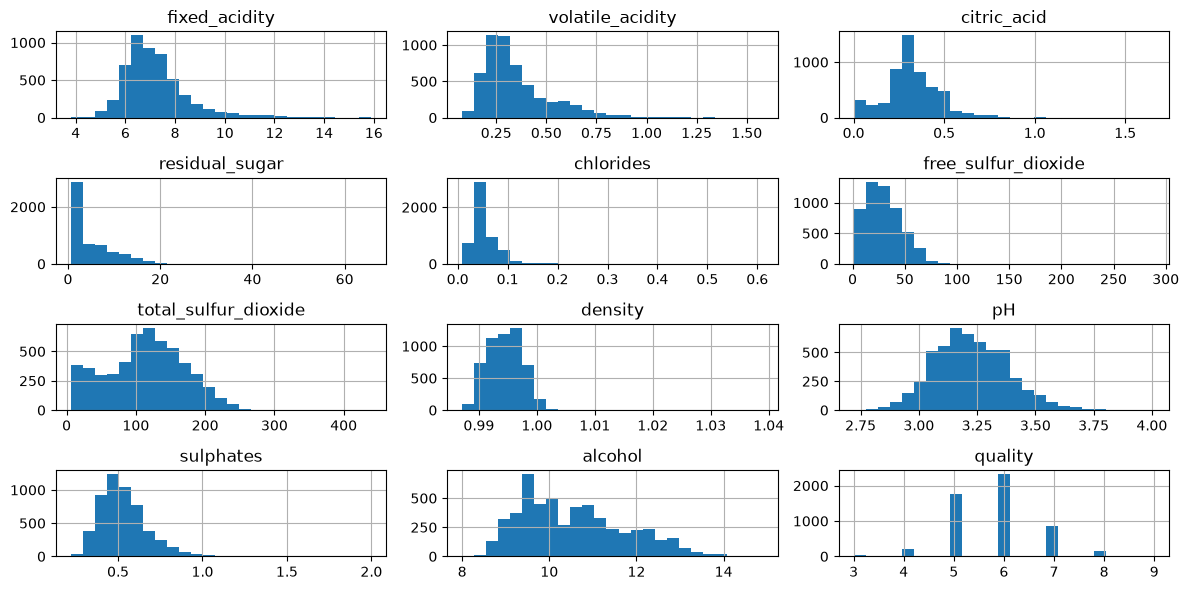

In [10]:
# Visualise the data using histplot

df.hist(bins=25, figsize=(12, 6))
plt.tight_layout()
plt.show()

# Based on Plot
# The histogram plots show that several features (volatile_acidity, residual_sugar, chlorides, free_sulfur_dioxide, total_sulfur_dioxide) 
# are strongly right‑skewed with long tails and contain extreme but valid outliers. 
# pH is fairly symmetric and evenly distributed. 
# Quality is discrete, imbalanced, and exhibits multiple peaks.
# Overall, most physicochemical variables contain rare extreme values that represent real observations rather than noise.

In [11]:
df.describe()

# the range of min and max is large so scaling will be required
# some features have extreme max values which suggest normalization and Transformation might be needed
# Some features (like density and alcohol) are inversely related, correlation analysis can reveal redundancy.
# The target variable quality is discrete and slightly imbalanced (most wines rated 5–6)

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
count,5318.000000,5318.000000,5318.000000,5318.000000,5318.000000,5318.000000,5318.000000,5318.000000,5318.000000,5318.000000,5318.000000,5318.000000
mean,7.215523,0.344171,0.318522,5.049605,0.056700,30.030463,114.107747,0.994536,3.224639,0.533402,10.549222,5.795600
std,1.319777,0.168264,0.147177,4.500645,0.036865,17.804365,56.783848,0.002966,0.160403,0.149753,1.185964,0.879715
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.240000,1.800000,0.038000,16.000000,74.000000,0.992200,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.300000,0.310000,2.700000,0.047000,28.000000,116.000000,0.994660,3.210000,0.510000,10.400000,6.000000
75%,7.700000,0.410000,0.400000,7.500000,0.066000,41.000000,153.750000,0.996770,3.330000,0.600000,11.400000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


In [12]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.to_list()
cat_cols = df.select_dtypes(include=['object', 'str']).columns.to_list()

print('Numerical Category: ', num_cols)
print()
print('Categorical Category: ', cat_cols)

Numerical Category:  ['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar', 'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']

Categorical Category:  []


In [14]:
# Checking for Skewness

skewed = df[num_cols].skew()
skewed_cols = skewed[skewed > 1].index.to_list()

print(skewed_cols)
print()
print(skewed)

['fixed_acidity', 'volatile_acidity', 'residual_sugar', 'chlorides', 'free_sulfur_dioxide', 'sulphates']

fixed_acidity           1.650055
volatile_acidity        1.504115
citric_acid             0.483817
residual_sugar          1.706027
chlorides               5.339077
free_sulfur_dioxide     1.363772
total_sulfur_dioxide    0.063667
density                 0.666033
pH                      0.390358
sulphates               1.809099
alcohol                 0.545866
quality                 0.147470
dtype: float64


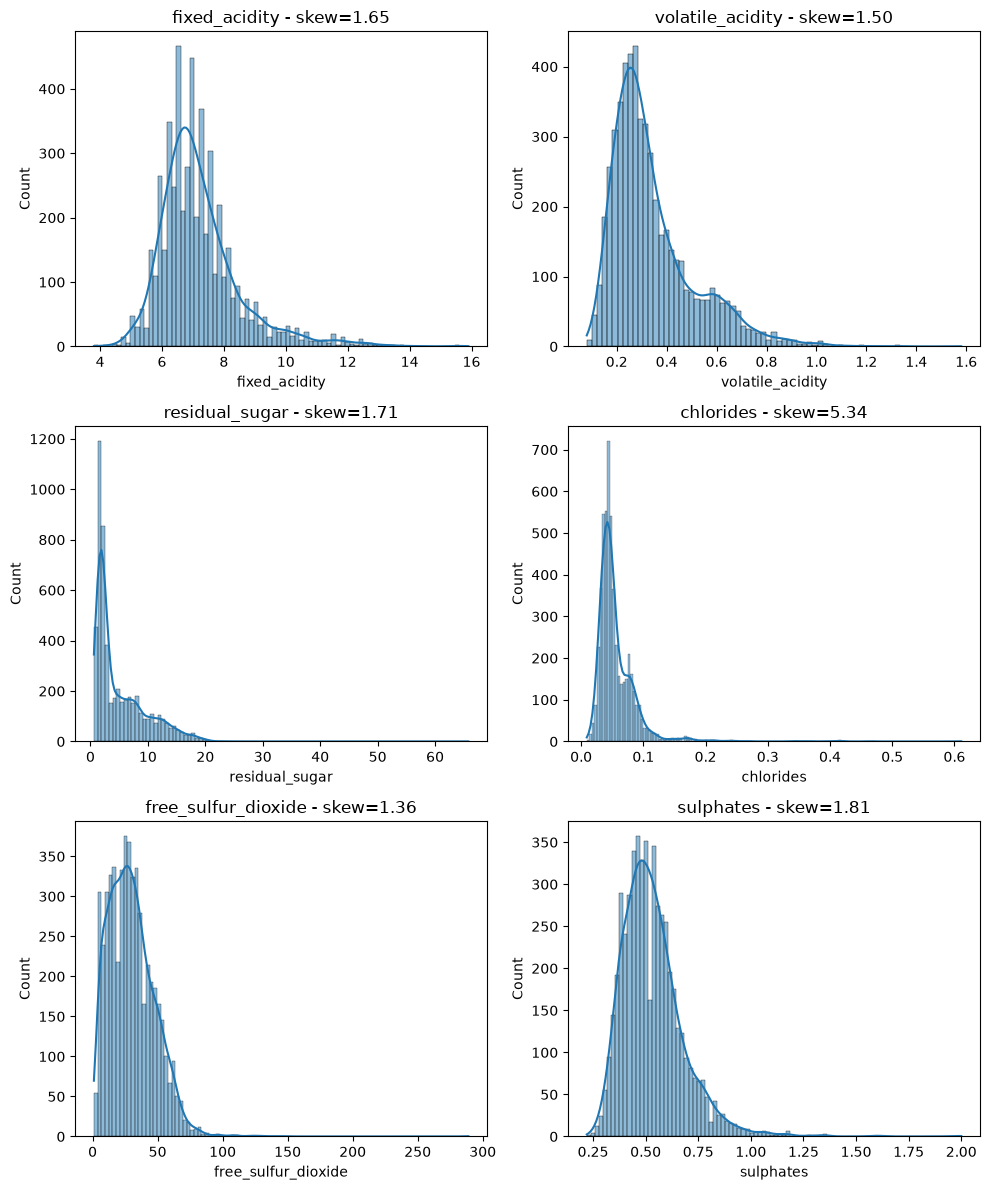

In [15]:
# visualize the skewed 

fig, axes = plt.subplots(3, 2, figsize=(10, 12))
axes = axes.flatten()
for col, ax in zip(skewed_cols, axes):
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(f'{col} - skew={df[col].skew():.2f}')

plt.tight_layout()
plt.show()

In [16]:
# check for outlier

outlier_cols = []
no_outlier_cols = []
outlier_summary = []

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outlier = df[(df[col] < lower) | (df[col] > upper)]

    if len(outlier) > 0:
        outlier_cols.append(col)
    else:
        no_outlier_cols.append(col)

    outlier_summary.append({
        'Columns': col,
        'Outlier Count': len(outlier),
        'Total Row': len(df),
        'Outlier %': round(len(outlier)/len(df) * 100, 2)
    })

outlier_table = pd.DataFrame(outlier_summary)

print("Columns with outliers:", outlier_cols)
print()
print("Columns without outliers:", no_outlier_cols)
print()
display(outlier_table.sort_values(by='Outlier Count', ascending=False))

Columns with outliers: ['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar', 'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']

Columns without outliers: []



,Columns,Outlier Count,Total Row,Outlier %
0,fixed_acidity,304,5318,5.72
1,volatile_acidity,279,5318,5.25
4,chlorides,237,5318,4.46
11,quality,183,5318,3.44
9,sulphates,163,5318,3.07
2,citric_acid,143,5318,2.69
3,residual_sugar,141,5318,2.65
8,pH,49,5318,0.92
5,free_sulfur_dioxide,44,5318,0.83
6,total_sulfur_dioxide,10,5318,0.19


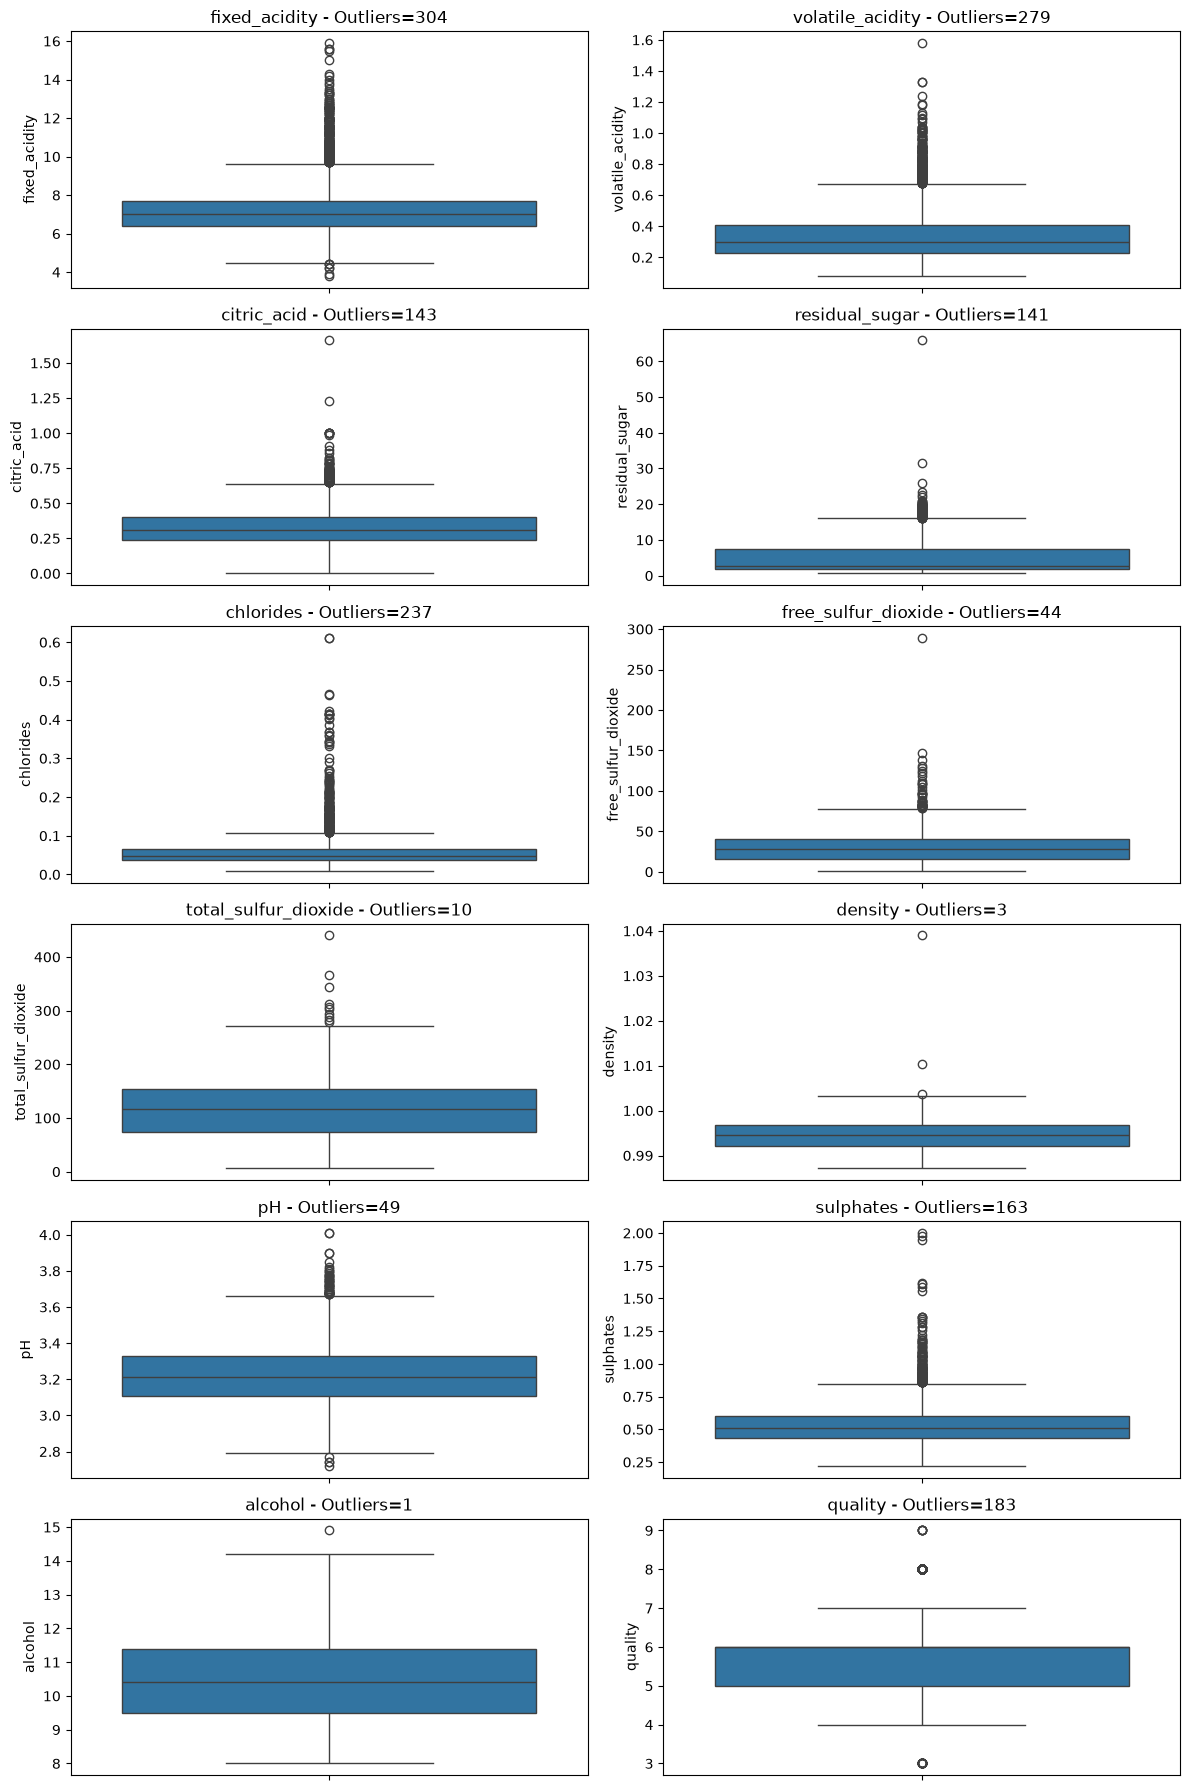

In [17]:
# Using boxplot to visualise Outliers

fig, axes = plt.subplots(6, 2, figsize=(12, 18))
axes = axes.flatten()

for col, ax in zip(outlier_cols, axes):
    sns.boxplot(df[col], ax=ax)

    # get outlier count for this column
    count = outlier_table.loc[outlier_table['Columns'] == col, 'Outlier Count'].values[0]

    ax.set_title(f'{col} - Outliers={count}')

# hide unused axes
for ax in axes[len(outlier_cols):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

In [18]:
# Checking for Correlations

df_corr = df.corr(numeric_only=True)
df_corr['quality'].sort_values(ascending=False)

quality                 1.000000
alcohol                 0.469216
citric_acid             0.097926
free_sulfur_dioxide     0.054199
sulphates               0.042040
pH                      0.039789
total_sulfur_dioxide   -0.050183
residual_sugar         -0.056824
fixed_acidity          -0.080190
chlorides              -0.201960
volatile_acidity       -0.265354
density                -0.326301
Name: quality, dtype: float64

In [19]:
''' 
Based on the exploratory data analysis, alcohol shows the strongest correlation with wine quality. 
 Other features have weak correlations, but they still contain meaningful information. 
 All columns contain real outliers, and six columns exhibit significant right‑skewness. 
 These skewed features require transformation before modeling. 
 The goal is to predict wine quality using physicochemical measurements. 
 The target variable is discrete, ordered, and imbalanced, with most wines rated as ordinary (5–6). 

 Deciding on model, loss function, and metrics:
 - This is a regression problem.
 - Suitable metrics include MAE, RMSE, and R².
 - Outliers should be kept, but skewed features should be transformed.

 Assignment Tasks:

 1. Train a Support Vector Machine Regressor (sklearn.svm.SVR) using various hyperparameters:
    - kernel="linear" with multiple C values
    - kernel="rbf" with multiple combinations of C and gamma
    Since SVR does not scale well to large datasets, use only the first 5,000 rows and 3‑fold cross‑validation.
    Evaluate how the best SVR model performs.

 2. Replace GridSearchCV with RandomizedSearchCV and compare performance and training time.

3. Add a SelectFromModel transformer to the preprocessing pipeline to automatically select the most important attributes before training the model.

 4. Create a custom transformer that trains a KNeighborsRegressor in its fit() method and outputs the model’s predictions in its transform() method. 
    Add this synthetic feature to the preprocessing pipeline so the model can use it as an additional input.

 5. Use GridSearchCV to automatically explore different preprocessing options, such as:
    - With or without SelectFromModel
    - Different scalers or transformers
    - Different SVR kernels and hyperparameters

 6. Implement a StandardScalerClone class from scratch:
    - fit(): compute mean_ and scale_
    - transform(): apply scaling
    - inverse_transform(): undo scaling so that 
      scaler.inverse_transform(scaler.fit_transform(X)) returns a result close to X
    - If the input is a DataFrame, store feature_names_in_ as a NumPy array of column names
    - Implement get_feature_names_out(input_features=None):
        • If input_features is provided, ensure its length matches n_features_in_ 
          and matches feature_names_in_ when defined; then return input_features.
        • If input_features is None, return feature_names_in_ if available,
          otherwise return np.array(["x0", "x1", ...]) with length n_features_in_.
'''

' \nBased on the exploratory data analysis, alcohol shows the strongest correlation with wine quality. \n Other features have weak correlations, but they still contain meaningful information. \n All columns contain real outliers, and six columns exhibit significant right‑skewness. \n These skewed features require transformation before modeling. \n The goal is to predict wine quality using physicochemical measurements. \n The target variable is discrete, ordered, and imbalanced, with most wines rated as ordinary (5–6). \n\n Deciding on model, loss function, and metrics:\n - This is a regression problem.\n - Suitable metrics include MAE, RMSE, and R².\n - Outliers should be kept, but skewed features should be transformed.\n\n Assignment Tasks:\n\n 1. Train a Support Vector Machine Regressor (sklearn.svm.SVR) using various hyperparameters:\n    - kernel="linear" with multiple C values\n    - kernel="rbf" with multiple combinations of C and gamma\n    Since SVR does not scale well to large

In [ ]:
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import PowerTransformer, StandardScaler
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.base import BaseEstimator, TransformerMixin
import numpy as np

skewed_features = [
    'fixed_acidity', 'volatile_acidity', 'residual_sugar',
    'chlorides', 'free_sulfur_dioxide', 'sulphates'
]

normal_features = [
    'citric_acid', 'total_sulfur_dioxide', 'density',
    'pH', 'alcohol'
]

preprocess = ColumnTransformer([
    ('skewed', Pipeline([
        ('power', PowerTransformer(method='yeo-johnson')),
        ('scale', StandardScaler())
    ]), skewed_features),
    ('normal', StandardScaler(), normal_features)
])

feature_selector = SelectFromModel(Lasso(alpha=0.001))

class KNNFeatureAdder(BaseEstimator, TransformerMixin):
    def __init__(self, n_neighbors=5):
        self.n_neighbors = n_neighbors
        self.knn = KNeighborsRegressor(n_neighbors=n_neighbors)

    def fit(self, X, y=None):
        self.knn.fit(X, y)
        return self

    def transform(self, X):
        return self.knn.predict(X).reshape(-1, 1)

knn_feature_pipeline = Pipeline([
    ('knn_feature', KNNFeatureAdder(n_neighbors=5))
])

class StandardScalerClone(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        X_arr = np.array(X)
        self.mean_ = X_arr.mean(axis=0)
        self.scale_ = X_arr.std(axis=0)
        self.n_features_in_ = X_arr.shape[1]
        if hasattr(X, "columns"):
            self.feature_names_in_ = np.array(X.columns)
        else:
            self.feature_names_in_ = None
        return self

    def transform(self, X):
        return (np.array(X) - self.mean_) / self.scale_

    def inverse_transform(self, X_scaled):
        return (np.array(X_scaled) * self.scale_) + self.mean_

    def get_feature_names_out(self, input_features=None):
        if input_features is not None:
            if len(input_features) != self.n_features_in_:
                raise ValueError("Input feature length mismatch.")
            if self.feature_names_in_ is not None:
                if not np.array_equal(input_features, self.feature_names_in_):
                    raise ValueError("Input features do not match stored names.")
            return np.array(input_features)
        if self.feature_names_in_ is not None:
            return self.feature_names_in_
        return np.array([f"x{i}" for i in range(self.n_features_in_])


In [21]:
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import PowerTransformer, StandardScaler
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.base import BaseEstimator, TransformerMixin
import numpy as np

skewed_features = [
    'fixed_acidity', 'volatile_acidity', 'residual_sugar',
    'chlorides', 'free_sulfur_dioxide', 'sulphates'
]

normal_features = [
    'citric_acid', 'total_sulfur_dioxide', 'density',
    'pH', 'alcohol'
]

preprocess = ColumnTransformer([
    ('skewed', Pipeline([
        ('power', PowerTransformer(method='yeo-johnson')),
        ('scale', StandardScaler())
    ]), skewed_features),
    ('normal', StandardScaler(), normal_features)
])

feature_selector = SelectFromModel(Lasso(alpha=0.001))

class KNNFeatureAdder(BaseEstimator, TransformerMixin):
    def __init__(self, n_neighbors=5):
        self.n_neighbors = n_neighbors
        self.knn = KNeighborsRegressor(n_neighbors=n_neighbors)

    def fit(self, X, y=None):
        self.knn.fit(X, y)
        return self

    def transform(self, X):
        return self.knn.predict(X).reshape(-1, 1)

knn_feature_pipeline = Pipeline([
    ('knn_feature', KNNFeatureAdder(n_neighbors=5))
])

full_pipeline = Pipeline([
    ('preprocess', preprocess),
    ('feature_select', feature_selector),
    ('knn_feature', KNNFeatureAdder(n_neighbors=5)),
    ('svr', SVR())
])

param_grid = {
    'svr__kernel': ['linear', 'rbf'],
    'svr__C': [0.1, 1, 10, 100],
    'svr__gamma': ['scale', 'auto']
}

grid_search = GridSearchCV(
    full_pipeline,
    param_grid,
    cv=3,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

random_search = RandomizedSearchCV(
    full_pipeline,
    param_distributions=param_grid,
    n_iter=10,
    cv=3,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    random_state=42
)

class StandardScalerClone(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        X_arr = np.array(X)
        self.mean_ = X_arr.mean(axis=0)
        self.scale_ = X_arr.std(axis=0)
        self.n_features_in_ = X_arr.shape[1]
        if hasattr(X, "columns"):
            self.feature_names_in_ = np.array(X.columns)
        else:
            self.feature_names_in_ = None
        return self

    def transform(self, X):
        return (np.array(X) - self.mean_) / self.scale_

    def inverse_transform(self, X_scaled):
        return (np.array(X_scaled) * self.scale_) + self.mean_

    def get_feature_names_out(self, input_features=None):
        if input_features is not None:
            if len(input_features) != self.n_features_in_:
                raise ValueError("Input feature length mismatch.")
            if self.feature_names_in_ is not None:
                if not np.array_equal(input_features, self.feature_names_in_):
                    raise ValueError("Input features do not match stored names.")
            return np.array(input_features)
        if self.feature_names_in_ is not None:
            return self.feature_names_in_
        return np.array([f"x{i}" for i in range(self.n_features_in_)])


In [23]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

X = df.drop('quality', axis=1)
y = df['quality']

grid_search.fit(X, y)
random_search.fit(X, y)

best_grid_model = grid_search.best_estimator_
best_random_model = random_search.best_estimator_

grid_pred = best_grid_model.predict(X)
random_pred = best_random_model.predict(X)

grid_mae = mean_absolute_error(y, grid_pred)
grid_rmse = np.sqrt(mean_squared_error(y, grid_pred))
grid_r2 = r2_score(y, grid_pred)

random_mae = mean_absolute_error(y, random_pred)
random_rmse = np.sqrt(mean_squared_error(y, random_pred))
random_r2 = r2_score(y, random_pred)

comparison = {
    "GridSearch": {
        "MAE": grid_mae,
        "RMSE": grid_rmse,
        "R2": grid_r2
    },
    "RandomSearch": {
        "MAE": random_mae,
        "RMSE": random_rmse,
        "R2": random_r2
    }
}

comparison


{'GridSearch': {'MAE': 0.4404440931518148,
  'RMSE': np.float64(0.6072116772430597),
  'R2': 0.5234834010382174},
 'RandomSearch': {'MAE': 0.4389412102413203,
  'RMSE': np.float64(0.6083241878103083),
  'R2': 0.5217356896101566}}

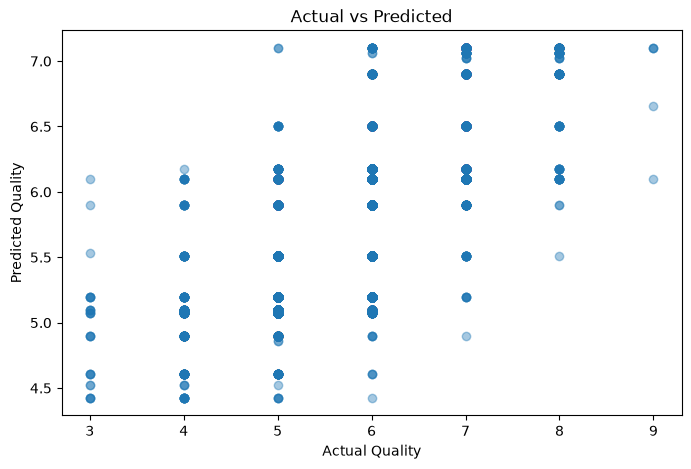

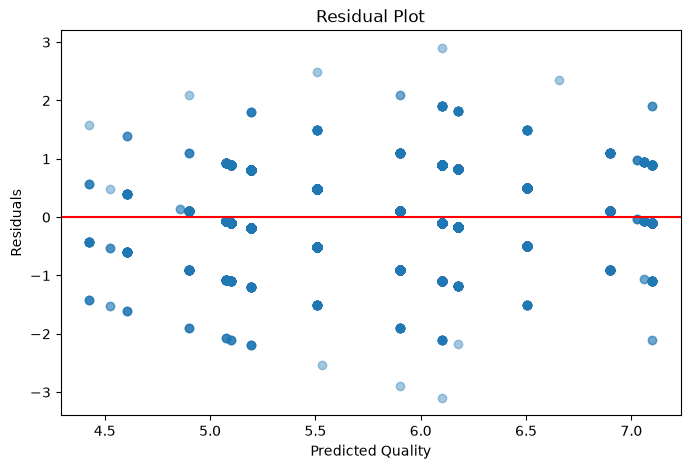

In [24]:
import matplotlib.pyplot as plt

best_model = best_random_model

pred = best_model.predict(X)

plt.figure(figsize=(8,5))
plt.scatter(y, pred, alpha=0.4)
plt.xlabel("Actual Quality")
plt.ylabel("Predicted Quality")
plt.title("Actual vs Predicted")
plt.show()

residuals = y - pred

plt.figure(figsize=(8,5))
plt.scatter(pred, residuals, alpha=0.4)
plt.axhline(0, color='red')
plt.xlabel("Predicted Quality")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()


